Rrgressione Ridge

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression


In [3]:
data = load_diabetes(as_frame=True)
X = data.data
y = data.target

display(X)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [4]:
# per prima cosa scaliamo i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)
y_pred_lin = lin_reg.predict(X_scaled)

mse_lin = mean_squared_error(y, y_pred_lin)
r2_lin = r2_score(y, y_pred_lin)

print(f"MSE (Linear):\t{mse_lin:.4f}\nR² (Linear):\t{r2_lin:.4f}")

MSE (Linear):	2859.6963
R² (Linear):	0.5177


In [6]:
r2_ridge = []
mse_ridge = []
# creiamo una variabile che crea un range di valori (da 10 alla -3 a 10 alla 3) distanziati di 100 per il parametro alpha
alphas = np.logspace(-3, 3, 100)

# crediamo un ciclo for che per ogni valore di alpha crea un modello di regressione ridge, lo addestra sui dati scalati, fa le predizioni e calcola MSE e R²

for a in alphas:
    # addestramento del modello Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled, y)
    y_pred_ridge = ridge.predict(X_scaled)
    
    # inserimento dei risultati nelle due liste
    mse_ridge.append(mean_squared_error(y, y_pred_ridge))
    r2_ridge.append(r2_score(y, y_pred_ridge))

# creiamo un dataframe che contiene i valori di alpha, MSE e R²

results = pd.DataFrame({"alpha": alphas, "MSE":mse_ridge, "R2": r2_ridge})
display(results)



,alpha,MSE,R2
0,0.001000,2859.696349,0.517748
1,0.001150,2859.696350,0.517748
2,0.001322,2859.696350,0.517748
3,0.001520,2859.696351,0.517748
4,0.001748,2859.696352,0.517748
...,...,...,...
95,572.236766,3371.028646,0.431519
96,657.933225,3442.890079,0.419400
97,756.463328,3520.738601,0.406272
98,869.749003,3604.369587,0.392169


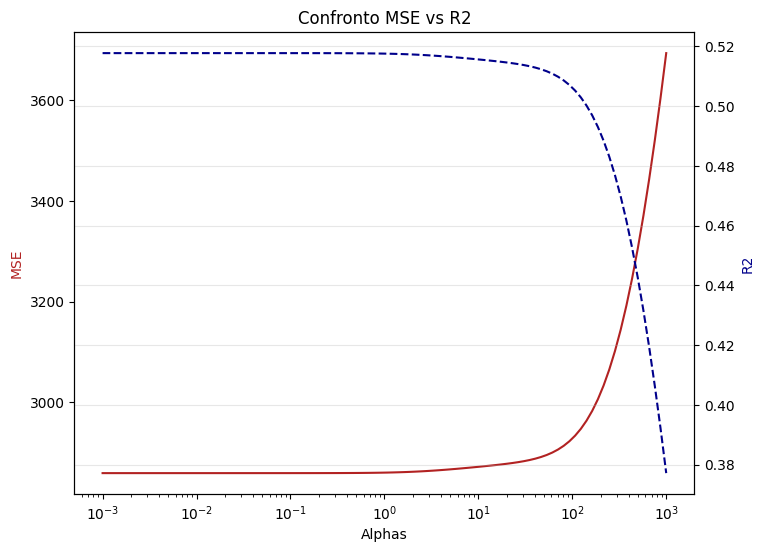

In [7]:
# creiamo un plot dei valori trovati

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(alphas, mse_ridge, "-", color="firebrick")
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE", color="firebrick")

# il metodo twinx crea un secondo oggetto axis che condivide lo stesso asse x di un grafico esistente ma una y diversa

ax2 = ax1.twinx()
ax2.plot(alphas, r2_ridge, "--", color="darkblue")
ax2.set_ylabel("R2", color = "darkblue")

plt.title("Confronto MSE vs R2")
plt.grid(alpha=0.3)
plt.show()


In [8]:
# allenamento dell'oggetto RidgeCV con la cross validation usando alpha

alphas_cv = alphas
ridge_cv = RidgeCV(alphas = alphas, store_cv_results = True)
ridge_cv.fit(X_scaled, y)

print(f"Alpha RidgeCV:\t{ridge_cv.alpha_:.4f}")

y_pred_cv = ridge_cv.predict(X_scaled)
mse_cv = mean_squared_error(y, y_pred_cv)
r2_cv = r2_score(y, y_pred_cv)

print(f"MSE:\t{mse_cv:.4f}\nR2:\t{r2_cv:.4f}")


Alpha RidgeCV:	1.8738
MSE:	2862.1789
R2:	0.5173


In [9]:
# verifichiamo qual è l'alpha ottimale

best_idx_man = np.argmin(mse_ridge)
best_alpha_man = alphas[best_idx_man]
best_mse_man = mse_ridge[best_idx_man]
best_r2_man = r2_ridge[best_idx_man]

print(f"Alpha Ridge:\t{best_alpha_man:.4f}\nMSE:\t{best_mse_man:.4f}\nR2:\t{best_r2_man:.4f}")

Alpha Ridge:	0.0010
MSE:	2859.6963
R2:	0.5177


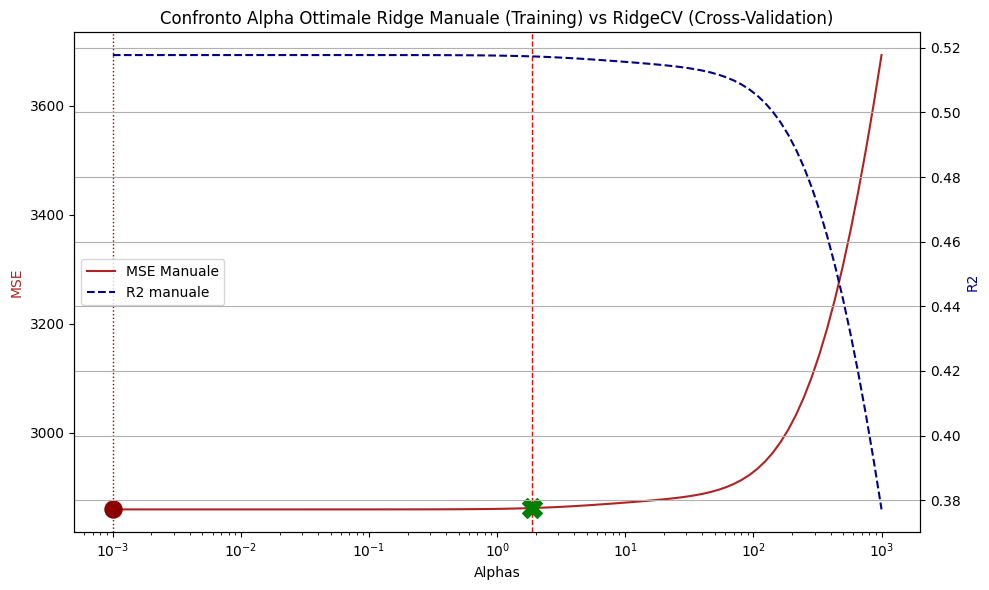

In [10]:
# plot di ridge andando a vedere l'alpha ottimale trovato manualmente che con la cross validation

fig, ax1 = plt.subplots(figsize=(10,6))

l1 = ax1.plot(alphas, mse_ridge, "-", color="firebrick", label = "MSE Manuale")
ax1.set_xscale("log")
ax1.set_xlabel("Alphas")
ax1.set_ylabel("MSE", color="firebrick")

# scatter plot degli alpha manuali
ax1.scatter(best_alpha_man, best_mse_man, color="darkred", s=150, zorder=5, label=f"n_manuale{best_alpha_man:.4f}")
ax1.axvline(best_alpha_man, color="darkred", linestyle=":", linewidth=1)

# scatter plot dell'alpha trovato con la cross validation
ax1.scatter(ridge_cv.alpha_, mean_squared_error(y, ridge_cv.predict(X_scaled)),
            color = "green", marker = "X", s=200, zorder=5,
            label = f"alpha Ridge={ridge_cv.alpha_:.4f}")
ax1.axvline(ridge_cv.alpha_, color="red", linestyle="--", linewidth=1)

ax2 = ax1.twinx()
l2 = ax2.plot(alphas, r2_ridge, "--", color="darkblue", label="R2 manuale")
ax2.set_ylabel("R2", color="darkblue")

plt.title(f"Confronto Alpha Ottimale Ridge Manuale (Training) vs RidgeCV (Cross-Validation)")
plt.grid()

lines = l1+l2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc = "center left")

plt.tight_layout()
plt.show()

Quello a sinistra è l'alpha ottimale, che si trova facendo il minimo di MSE e il massimo di r2. 
Come vediamo però c'è una grande distanza con l'alpha ottimale rappresentato con la x e trovato con la cross-validation. 
I valori di r2 e MSE non hanno grandi variazioni fino a quando alpha = 100